# 01. Filtrado estadístico de las cabezas de atención de ESM-2

Evaluación estadística de los tensores de atención del PLM ESM-2 (650M: L = 33 y H = 20) adaptando el protocolo de Dong et al. (2024) para identificar y aislar las cabezas de atención que codifican las señales asociadas al alosterismo.

Para ello se procesan los resultados de un modelo nulo de Monte Carlo mediante la cuantificación del impacto alostérico, la relación señal-ruido (SNR) y la significancia estadística (p-valor).

## 1) Librerías y datos

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from IPython.display import display, HTML

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'legend.frameon': False
})

input_path = "../results/tables/Raw_Head_Stats.csv"
output_table_path = "../results/tables/Selected_Attention_Heads.csv"

if not os.path.exists(input_path):
    raise FileNotFoundError(f"No se encuentra el archivo de entrada en: {input_path}")

df_raw = pd.read_csv(input_path)

# Reconstrucción del espacio completo de la red (33 capas x 20 cabezas = 660 combinaciones)
all_layers = np.arange(33)
all_heads = np.arange(20)
full_grid = pd.MultiIndex.from_product([all_layers, all_heads], names=["Layer", "Head"]).to_frame(index=False)

# Fusión y curación de valores nulos (NaN) para homogeneizar la matriz
df_full = pd.merge(full_grid, df_raw, on=["Layer", "Head"], how="left")
df_full["Impact"] = df_full["Impact"].fillna(0.0)
df_full["SNR"] = df_full["SNR"].fillna(0.0)
df_full["P_val"] = df_full["P_val"].fillna(1.0)

print(f"Éxito: Matriz curada inicializada con {df_full.shape[0]} cabezas de atención.")

Éxito: Matriz curada inicializada con 660 cabezas de atención.


## 2) Distribución real ESM-2 vs distribución normal teórica


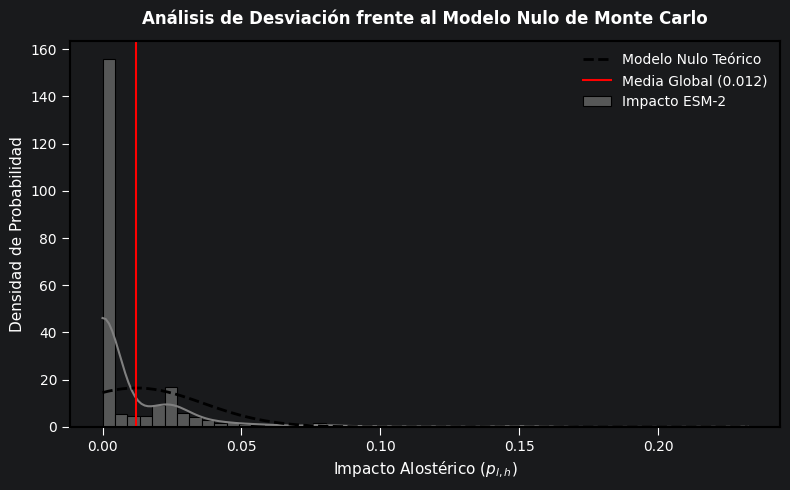

In [9]:
# Cálculo de estadísticos descriptivos globales
mean_impact = df_raw["Impact"].mean()
std_impact = df_raw["Impact"].std()

plt.figure(figsize=(8, 5))
# Histograma de los datos reales de impacto alostérico frente a la densidad empírica
sns.histplot(df_full["Impact"], kde=True, stat="density", color="gray", alpha=0.6, label="Impacto ESM-2")

# Superposición de la distribución normal teórica del modelo nulo
x = np.linspace(df_full["Impact"].min(), df_full["Impact"].max(), 100)
plt.plot(x, norm.pdf(x, mean_impact, std_impact), color="black", linestyle="--", linewidth=2, label="Modelo Nulo Teórico")

plt.axvline(mean_impact, color="red", linestyle="-", label=f"Media Global ({mean_impact:.3f})")
plt.title("Análisis de Desviación frente al Modelo Nulo de Monte Carlo", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Impacto Alostérico ($p_{l,h}$)", fontsize=11)
plt.ylabel("Densidad de Probabilidad", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

La asimetría de la distribución global evidencia que la gran mayoría de matrices de atención del modelo ESM-2 carecen de sensibilidad ante el alosterismo (impacto alostérico 0).

La superposición del modelo nulo justifica el uso de los filtros para discriminar el ruido de fondo y aislar las cabezas de la cola derecha (p < 0.01) que codifican el acoplamiento alostérico.

## 3) Filtros y exportación

In [10]:
# Aplicación del triple filtro de Dong et al. (2024)
df_full["Selected"] = (df_full["Impact"] > mean_impact) & (df_full["SNR"] > 2.0) & (df_full["P_val"] < 0.01)

# Aislamiento de las cabezas que superan el umbral estadístico
selected_heads = df_full[df_full["Selected"]].copy()

# Guardado sistemático en la carpeta de resultados procesados
selected_heads.to_csv(output_table_path, index=False)

print(f"Filtro completado: Se han aislado {selected_heads.shape[0]} cabezas de atención sensibles al alosterismo.")
print(f"Ruta de exportación: {output_table_path}")

Filtro completado: Se han aislado 14 cabezas de atención sensibles al alosterismo.
Ruta de exportación: ../results/tables/Selected_Attention_Heads.csv


## 4) Mapa de calor

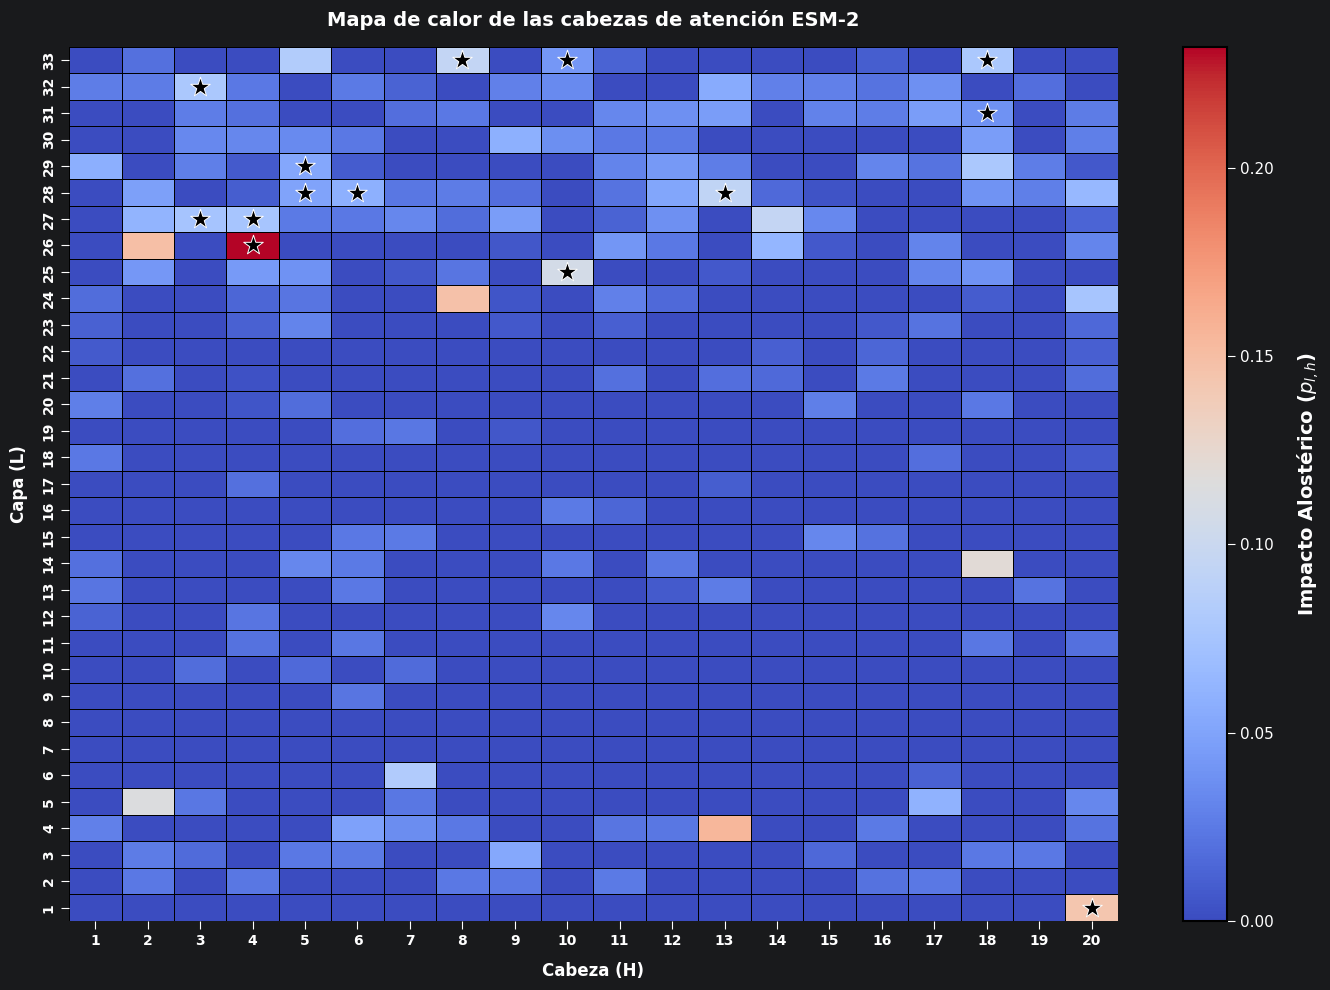

Layer,Head,Impact,SNR,P_val
26,4,0.2322,3.94,0.000e+00
1,20,0.1433,3.39,0.000e+00
25,10,0.1076,3.14,0.000e+00
33,8,0.0947,2.16,0.000e+00
28,13,0.0932,2.63,0.000e+00
33,18,0.0787,2.01,0.000e+00
32,3,0.0785,2.83,0.000e+00
27,4,0.0760,3.80,0.000e+00
27,3,0.0750,2.61,0.000e+00
28,6,0.0587,2.15,0.000e+00


In [11]:
# Pivotar el DataFrame para construir las matrices tridimensionales de visualización
matrix_impact = df_full.pivot(index="Layer", columns="Head", values="Impact")
matrix_selected = df_full.pivot(index="Layer", columns="Head", values="Selected")

# Inicialización del lienzo gráfico
fig, ax = plt.subplots(figsize=(14, 10))

# Generación del mapa de calor
sns.heatmap(
    matrix_impact,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="black",
    cbar=True,
    ax=ax
)

# Estilización avanzada de la barra de color (Colorbar)
colorbar = ax.collections[0].colorbar
colorbar.ax.set_ylabel('Impacto Alostérico ($p_{l,h}$)', fontsize=14, fontweight='bold', labelpad=15)
colorbar.ax.tick_params(labelsize=11)
colorbar.outline.set_linewidth(1.5)
colorbar.outline.set_color('black')

# Superposición geométrica de marcadores de significación
y_indices, x_indices = np.where(matrix_selected.values)
ax.scatter(
    x_indices + 0.5,
    y_indices + 0.5,
    marker='*',
    color='black',
    edgecolors='white',
    linewidths=0.7,
    s=220,
    zorder=10,
    label="Cabezas Seleccionadas ($p < 0.01$)"
)

# Configuración y corrección del indexado de los ejes (Escala biológica de 1 a N)
ax.set_title("Mapa de calor de las cabezas de atención ESM-2", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Cabeza (H)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Capa (L)", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xticks(np.arange(20) + 0.5)
ax.set_xticklabels([str(h + 1) for h in range(20)], fontsize=10, fontweight="bold")

ax.set_yticks(np.arange(33) + 0.5)
ax.set_yticklabels([str(l + 1) for l in range(33)], fontsize=10, fontweight="bold")

# Orientación estándar de capas (Capa 1 en la región superior)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n") # Espacio visual
display(HTML("<h3>Resumen Topológico: Cabezas de Atención Seleccionadas</h3>"))

# Asumiendo que 'selected_heads' se creó en el apartado anterior del cuaderno.
# Formateamos la tabla para que sea digna de una publicación:
tabla_visual = selected_heads.copy()
# Sumamos 1 a las capas y cabezas para que coincidan con la nomenclatura biológica (1-33 y 1-20)
tabla_visual["Layer"] = tabla_visual["Layer"] + 1
tabla_visual["Head"] = tabla_visual["Head"] + 1

# Ordenamos por Impacto descendente para ver las más importantes primero
tabla_visual = tabla_visual.sort_values(by="Impact", ascending=False).reset_index(drop=True)

# Mostramos la tabla con un estilo limpio de Pandas
display(tabla_visual[["Layer", "Head", "Impact", "SNR", "P_val"]].style.format({
    "Impact": "{:.4f}",
    "SNR": "{:.2f}",
    "P_val": "{:.3e}"
}).set_properties(**{'text-align': 'center'}).hide(axis="index"))

Se han seleccionado 14 cabezas de atención, de las cuales 13 se encuentran en capas profundas (25-33) y una en la capa inicial (1)

## 5) Atención acumulada hacia el sitio alostérico

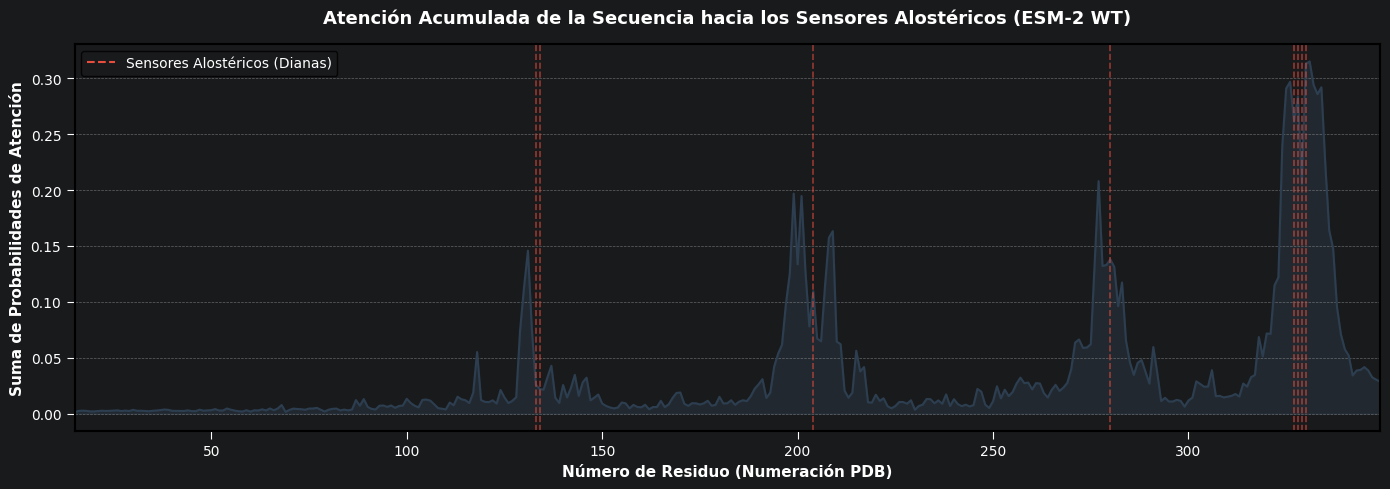

Residue_PDB,Cumulative_Attention
331,0.3150
330,0.3127
326,0.2968
332,0.2942
334,0.2919
325,0.2910
333,0.2858
328,0.2836
327,0.2610
324,0.2397


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definición del sitio alostérico objetivo (Sensores dinámicos de la PKA)
target_pdb_ids = [133, 134, 204, 280, 327, 328, 329, 330]
offset = 14 # Desfase de la secuencia FASTA respecto al cristal

# Conversión de numeración PDB a índices matriciales (Índice = PDB - 1 - offset)
target_indices = [pdb - 1 - offset for pdb in target_pdb_ids]

# 2. Carga y colapso del tensor de atención filtrado (WT)
tensor_path = "../data/processed/clean_attention_PKA_Allostery_WT.pt"
clean_tensor = torch.load(tensor_path, map_location="cpu", weights_only=True)

# Promediamos las 14 cabezas para obtener el consenso de atención alostérica
consensus_matrix = torch.mean(clean_tensor, dim=0).numpy()
seq_len = consensus_matrix.shape[0]

# 3. Cálculo de la Atención Acumulada
# Sumamos la atención que cada fila (residuo i) presta a las columnas (residuos del sitio alostérico)
cumulative_attention = np.sum(consensus_matrix[:, target_indices], axis=1)

# Construcción de un DataFrame para su graficación
df_accum = pd.DataFrame({
    "Residue_PDB": np.arange(seq_len) + 1 + offset,
    "Cumulative_Attention": cumulative_attention
})

# 4. Visualización del Perfil de Atención Acumulada
fig, ax = plt.subplots(figsize=(14, 5))

# Trazado del perfil continuo
ax.plot(df_accum["Residue_PDB"], df_accum["Cumulative_Attention"], color="#2c3e50", linewidth=1.5)
ax.fill_between(df_accum["Residue_PDB"], df_accum["Cumulative_Attention"], color="#34495e", alpha=0.3)

# Resaltar la ubicación física de los residuos diana (el propio sitio alostérico)
for target in target_pdb_ids:
    ax.axvline(x=target, color="#e74c3c", linestyle="--", alpha=0.6, linewidth=1.2)

# Crear leyenda fantasma para explicar las líneas rojas
ax.plot([], [], color="#e74c3c", linestyle="--", label="Sensores Alostéricos (Dianas)")

ax.set_title("Atención Acumulada de la Secuencia hacia los Sensores Alostéricos (ESM-2 WT)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Número de Residuo (Numeración PDB)", fontsize=11, fontweight="bold")
ax.set_ylabel("Suma de Probabilidades de Atención", fontsize=11, fontweight="bold")
ax.set_xlim(df_accum["Residue_PDB"].min(), df_accum["Residue_PDB"].max())
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc="upper left", frameon=True, edgecolor="black")

plt.tight_layout()
plt.show()

# 5. Extracción de los 10 residuos con mayor acoplamiento
top_residues = df_accum.sort_values(by="Cumulative_Attention", ascending=False).head(10).reset_index(drop=True)
display(HTML("<h3>Top 10 Residuos con Mayor Atención hacia el Sitio Alostérico</h3>"))
display(top_residues.style.format({
    "Cumulative_Attention": "{:.4f}"
}).set_properties(**{'text-align': 'center'}).hide(axis="index"))